## ELE632 Lab 4
#### Terry Chen 501236148

In [150]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftshift, ifft, ifftshift
from scipy.signal import convolve, freqz

#### Part A: Discrete-Time Fourier Transform (DTFT)

The ***fft*** commands from the ***SciPy*** library will be used to calculate the Discrete-Time Fourier Transform of signals


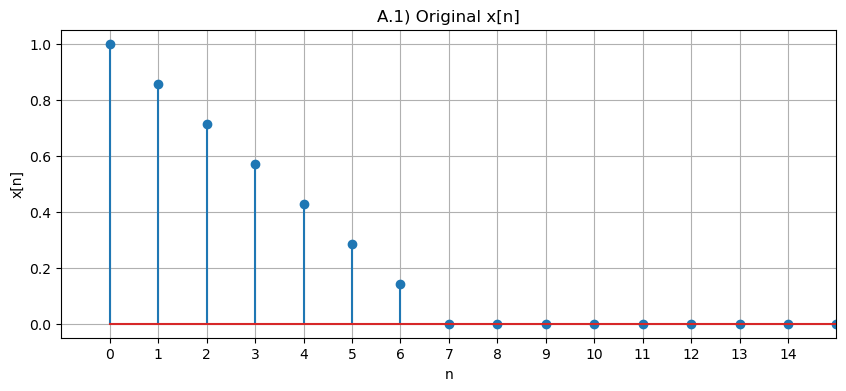

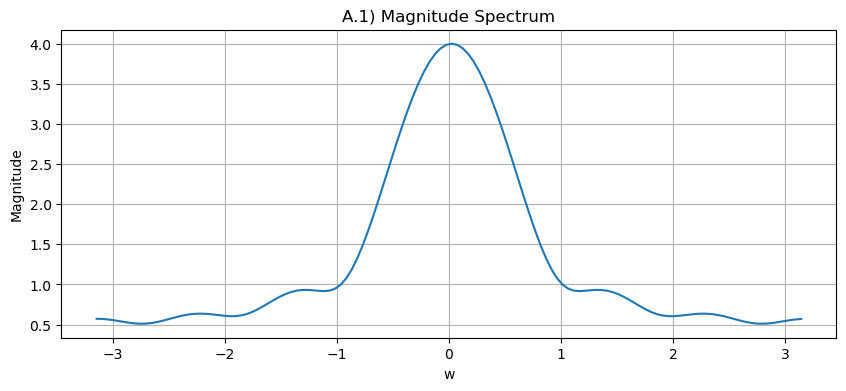

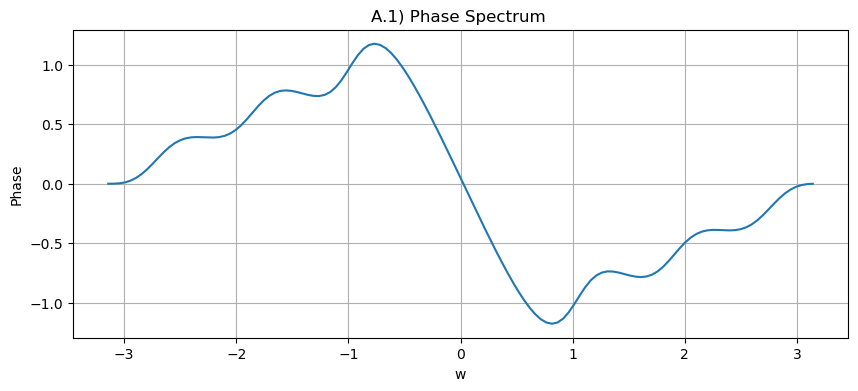

In [158]:
# x[n]
n = np.arange(0, 128)
xn_ramp = np.array([7/7, 6/7, 5/7, 4/7, 3/7, 2/7, 1/7, 0])
xn = np.zeros(128)
xn[:len(xn_ramp)] = xn_ramp

# DTFT from FFT
X_omega = fft(xn)
X_shifted = fftshift(X_omega)

# freq axis pi to pi
omega = np.linspace(-np.pi, np.pi, len(xn))

# og signal
plt.figure(figsize=(10, 4))
plt.stem(n, xn)
plt.title('A.1) Original x[n]')
plt.xlabel('n')
plt.ylabel('x[n]')
plt.xticks(np.arange(0, 15, 1)) 
plt.xlim([-1, 15])              
plt.grid()
plt.show()

# magnitude plot
plt.figure(figsize=(10, 4))
plt.plot(omega, np.abs(X_shifted))
plt.title('A.1) Magnitude Spectrum')
plt.xlabel('w')
plt.ylabel('Magnitude')
plt.grid()
plt.show()

# phase plot
plt.figure(figsize=(10, 4))
plt.plot(omega, np.angle(X_shifted))
plt.title('A.1) Phase Spectrum ')
plt.xlabel('w')
plt.ylabel('Phase')
plt.grid()
plt.show()


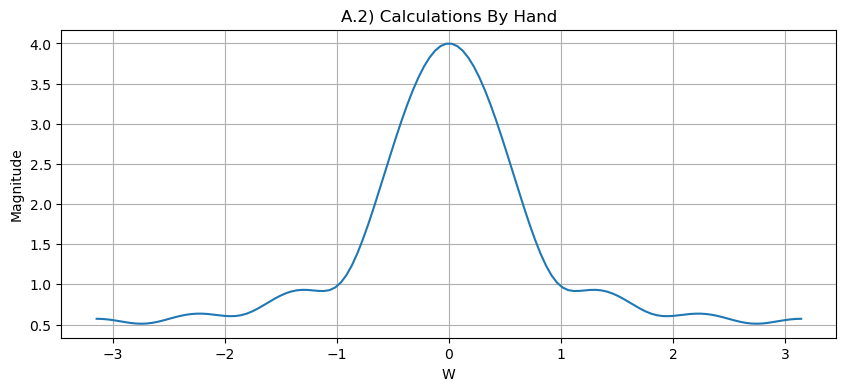

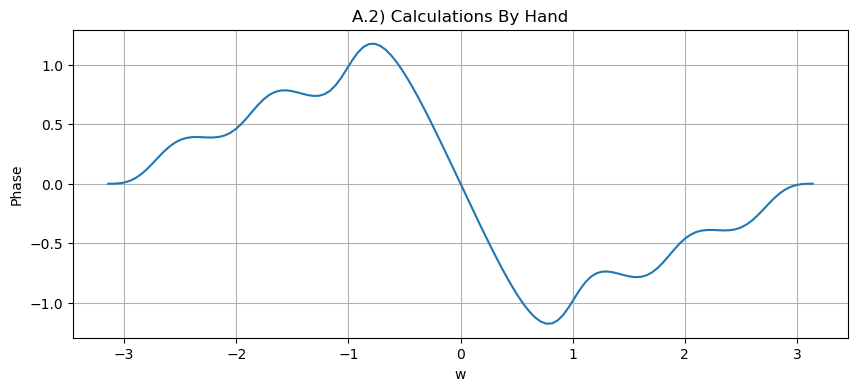

In [160]:
# A.2)
omega = np.linspace(-np.pi, np.pi, 128)
X_A2 = (xn[0] * np.exp(-1j * omega * 0) + 
        xn[1] * np.exp(-1j * omega * 1) + 
        xn[2] * np.exp(-1j * omega * 2) + 
        xn[3] * np.exp(-1j * omega * 3) + 
        xn[4] * np.exp(-1j * omega * 4) + 
        xn[5] * np.exp(-1j * omega * 5) + 
        xn[6] * np.exp(-1j * omega * 6))

plt.figure(figsize=(10, 4))
plt.plot(omega, np.abs(X_A2))
plt.title('A.2) Calculations By Hand')
plt.xlabel('W')
plt.ylabel('Magnitude')
plt.grid()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(omega, np.angle(X_A2))
plt.title('A.2) Calculations By Hand')
plt.xlabel('w')
plt.ylabel('Phase')
plt.grid()
plt.show()


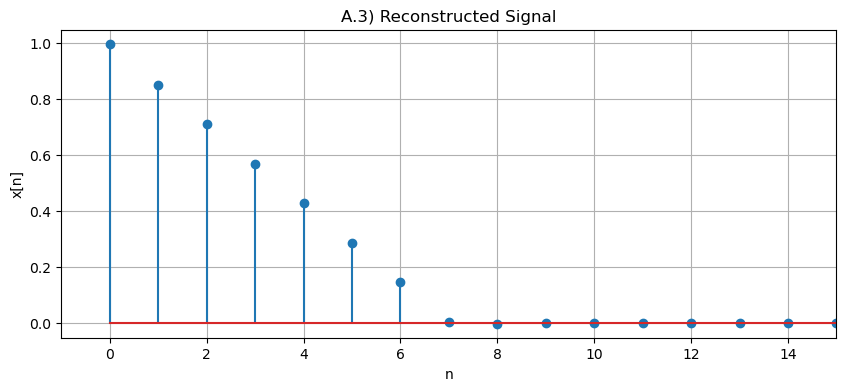

In [121]:
# A.3)
X_unshifted = ifftshift(X_A2)
xn_reconstructed = ifft(X_unshifted)

plt.figure(figsize=(10, 4))
plt.stem(np.arange(128), xn_reconstructed.real)
plt.title('A.3) Reconstructed Signal')
plt.xlabel('n')
plt.ylabel('x[n]')
plt.xlim([-1, 15])
plt.grid()
plt.show()

#### Part B: Time Convolution
matrix-based approach 

$S = 3$

$$x[n] = \sin(\frac{2\pi n}{(S + 1)})(u[n] -u[n-(S+1)])$$


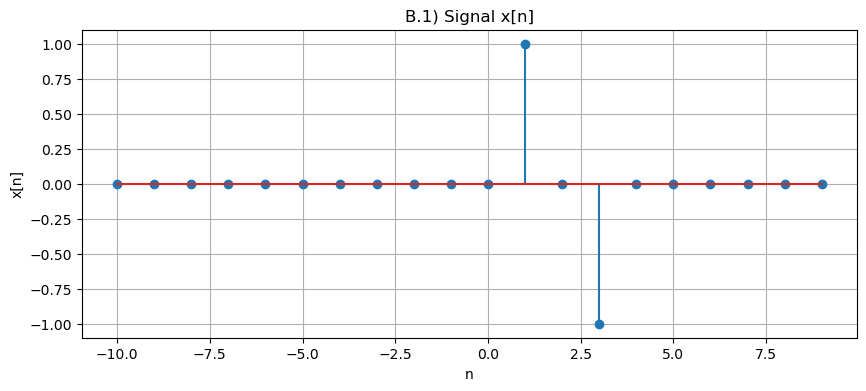

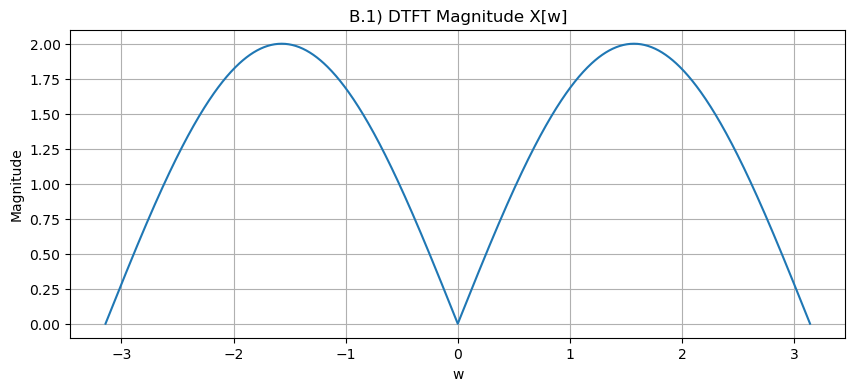

In [154]:
S = 3
n = np.arange(-10, 10)
xn = np.sin(2 * np.pi * n / (S+1)) * (n >= 0) * (n < (S+1))

omega = np.linspace(-np.pi, np.pi, 1001)
W_omega = np.exp(-1j)**np.dot((np.arange(xn.size).reshape(xn.size,1)), omega.reshape(1,1001))
X = np.dot(xn, W_omega)

# x[n] plot
plt.figure(figsize=(10, 4))
plt.stem(n, xn)
plt.title('B.1) Signal x[n]')
plt.xlabel('n')
plt.ylabel('x[n]')
plt.grid()
plt.show()

# magnitude plot
plt.figure(figsize=(10, 4))
plt.plot(omega, np.abs(X))
plt.title('B.1) DTFT Magnitude X[w]')
plt.xlabel('w')
plt.ylabel('Magnitude')
plt.grid()
plt.show()

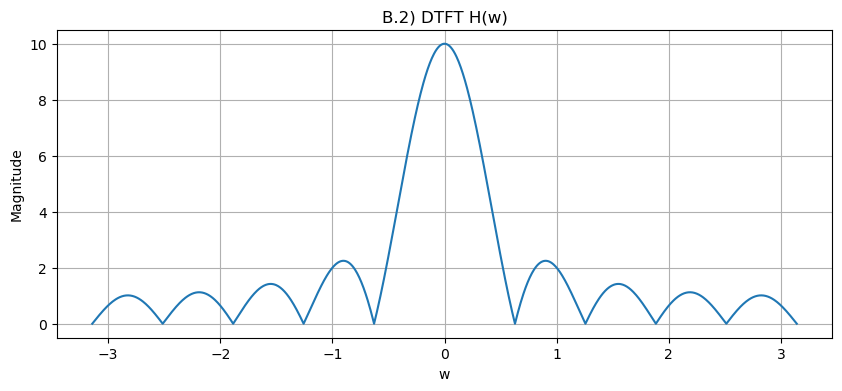

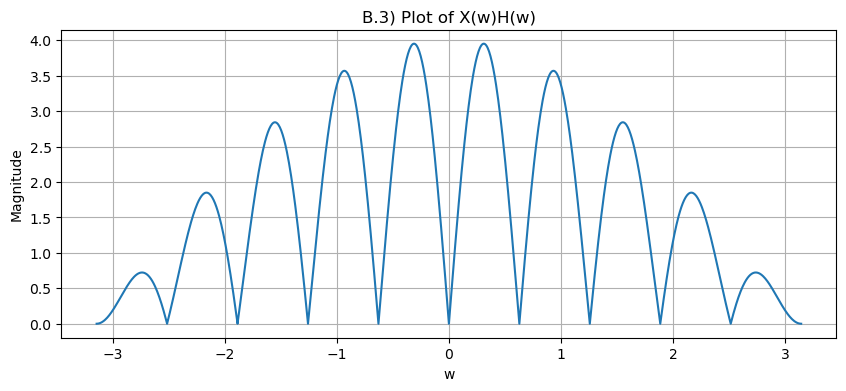

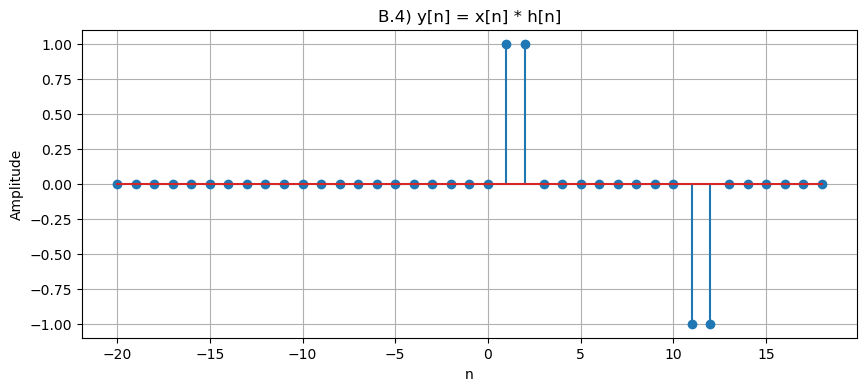

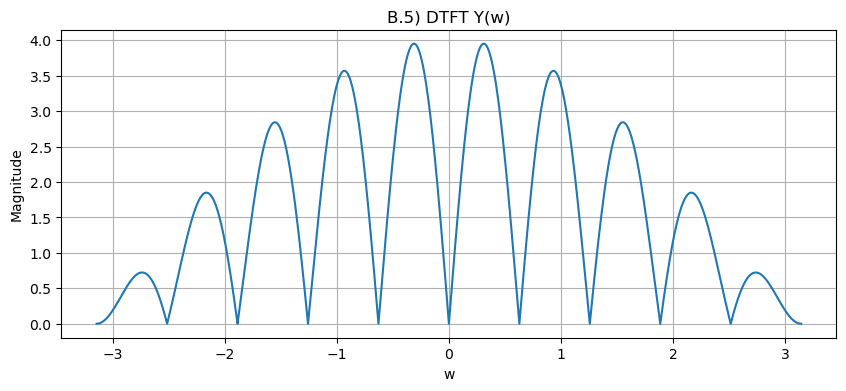

In [126]:
# B.2)
hn = (n >= 0) * (n < 10)
H = np.dot(hn, W_omega)

plt.figure(figsize=(10, 4))
plt.plot(omega, np.abs(H))
plt.title('B.2) DTFT H(w)')
plt.xlabel('w')
plt.ylabel('Magnitude')
plt.grid()
plt.show()


# B.3)
Y = X * H

plt.figure(figsize=(10, 4))
plt.plot(omega, np.abs(Y))
plt.title('B.3) Plot of X(w)H(w)')
plt.xlabel('w')
plt.ylabel('Magnitude')
plt.grid()
plt.show()

# B.4)
yn = convolve(xn, hn)
ny = np.arange(-20, -20 + len(yn))

plt.figure(figsize=(10, 4))
plt.stem(ny, yn)
plt.title('B.4) y[n] = x[n] * h[n]')
plt.xlabel('n')
plt.ylabel('Amplitude')
plt.grid()
plt.show()


# B.5)
W_omega_y = np.exp(-1j)**np.dot(np.arange(yn.size).reshape(yn.size, 1), omega.reshape(1, 1001))
Y_conv = np.dot(yn, W_omega_y)

plt.figure(figsize=(10, 4))
plt.plot(omega, np.abs(Y_conv))
plt.title('B.5) DTFT Y(w)')
plt.xlabel('w')
plt.ylabel('Magnitude')
plt.grid()
plt.show()

#### Part C: FIR Filter Design by Frequency Sampling


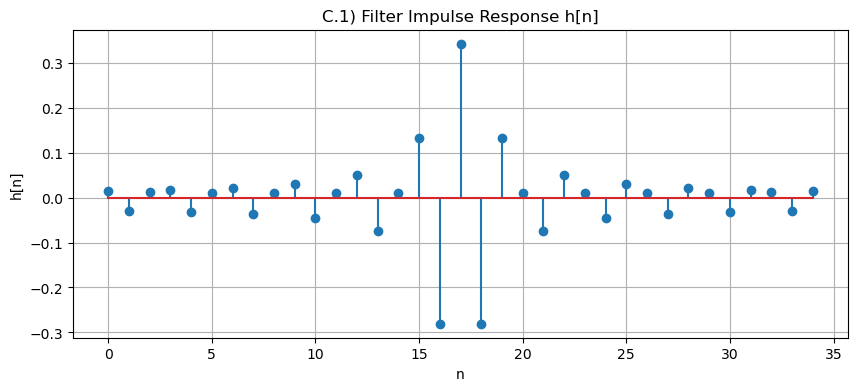

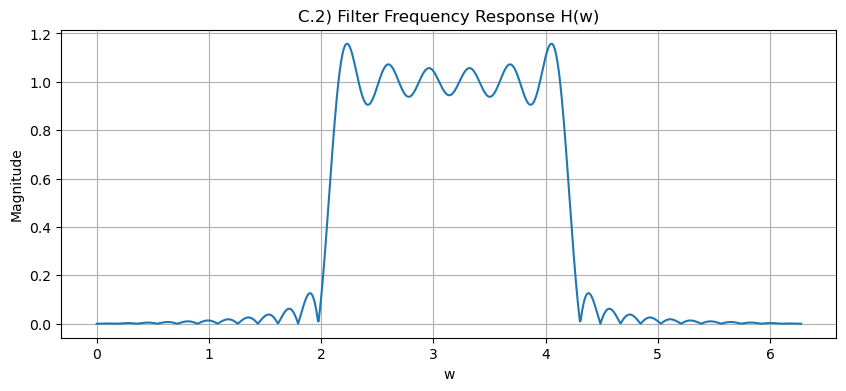

In [155]:
N = 35
Omega_0 = 2 * np.pi / 3
n_filt = np.arange(N)
Omega_n = 2 * np.pi * n_filt / N

H = np.zeros(N)
for i in range(N):
    # frequencies from Omega0 to (2*pi - Omega0)
    if (Omega_n[i] > Omega_0) and (Omega_n[i] < (2*np.pi - Omega_0)):
        H[i] = 1

hn = ifft(H)
hn_real = np.real(hn)
hn_filt = fftshift(hn_real)

plt.figure(figsize=(10, 4))
plt.stem(n_filt, hn_filt)
plt.title('C.1) Filter Impulse Response h[n]')
plt.xlabel('n')
plt.ylabel('h[n]')
plt.grid()
plt.show()

# C.2)
w, H = freqz(hn_filt, 1, worN = np.arange(0, 2*np.pi, 2*np.pi/1001))

plt.figure(figsize=(10, 4))
plt.plot(w, np.abs(H))
plt.title('C.2) Filter Frequency Response H(w)')
plt.xlabel('w')
plt.ylabel('Magnitude')
plt.grid()
plt.show()

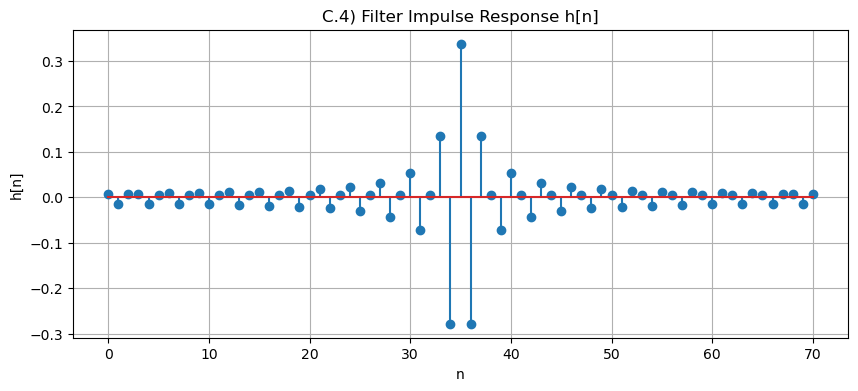

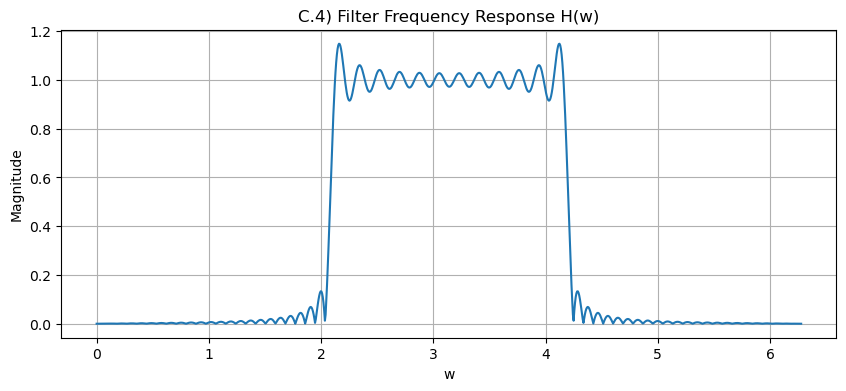

In [156]:
# C.4)
N = 71
Omega_0 = 2 * np.pi / 3
n_filt = np.arange(N)
Omega_n = 2 * np.pi * n_filt / N

H = np.zeros(N)
for i in range(N):
    # frequencies from Omega0 to (2*pi - Omega0)
    if (Omega_n[i] > Omega_0) and (Omega_n[i] < (2*np.pi - Omega_0)):
        H[i] = 1

hn = ifft(H)
hn_real = np.real(hn)
hn_filt = fftshift(hn_real)

plt.figure(figsize=(10, 4))
plt.stem(n_filt, hn_filt)
plt.title('C.4) Filter Impulse Response h[n]')
plt.xlabel('n')
plt.ylabel('h[n]')
plt.grid()
plt.show()

w, H = freqz(hn_filt, 1, worN = np.arange(0, 2*np.pi, 2*np.pi/1001))

plt.figure(figsize=(10, 4))
plt.plot(w, np.abs(H))
plt.title('C.4) Filter Frequency Response H(w)')
plt.xlabel('w')
plt.ylabel('Magnitude')
plt.grid()
plt.show()